In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    create_metro_submission,
    create_metro_quantile_submission,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_metrocast_quantiles,
    get_metrocast_horizons,
)

## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202620"
REFERENCE_DATE = "2026-05-23"
WINDOW = "202550-202619"

Choose baseline:

In [3]:
BASELINE = False
BASELINE_VAR_MULT = 5

These configs are unlikely to need changing:

In [4]:
DIST_FUNC = "rmse"
STRAINS = "h1-h3-b"
TARGET = "metro"
TARGET_LONG = "metrocast"
LOCAL_PARENT_DIR = "../experiments/multistrain"

Derived config values:

In [5]:
VALUE_COL = "target_total" if BASELINE else "target_sum"
MULTISTRAIN_EXPERIMENT = f"multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}"
WORKING_DIR = f"{LOCAL_PARENT_DIR}/{SUBMISSION_WEEK}-{TARGET}/{MULTISTRAIN_EXPERIMENT}"
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-06-20 00:00:00')

## Data

In [6]:
# Load single-strain submission file
single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202620/metro_smc_rmse_202550-202619/20260520-182258-83d476a6/outputs/20260520-205427/output_hub_formatted.csv.gz to file:///tmp/tmp0o0zi992/output_hub_formatted.csv.gz
  
.


Downloaded: output_hub_formatted.csv.gz


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,denver,2026-05-23,0,2026-05-23,Flu ED visits pct,quantile,0.025,0.0
1,denver,2026-05-23,1,2026-05-30,Flu ED visits pct,quantile,0.025,0.0
2,denver,2026-05-23,2,2026-06-06,Flu ED visits pct,quantile,0.025,0.0
3,denver,2026-05-23,3,2026-06-13,Flu ED visits pct,quantile,0.025,0.0
4,denver,2026-05-23,0,2026-05-23,Flu ED visits pct,quantile,0.05,0.0


In [7]:
from scipy.stats import beta

def beta_from_mean_var(mu, var):
    if var <= 0 or var >= mu * (1 - mu):
        raise ValueError("Need 0 < var < mu*(1-mu)")
    nu = mu * (1 - mu) / var - 1
    return mu * nu, (1 - mu) * nu

def ed_baseline_sample(baseline_mean):
    baseline_var = baseline_mean / 1000 * BASELINE_VAR_MULT
    a, b = beta_from_mean_var(baseline_mean, baseline_var)
    dist = beta(a, b)
    return dist.rvs(40000)

In [8]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_scaled_multi.csv")
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['date'])

# Compute quantiles
random_combined = pd.read_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz")

if BASELINE:
    baselines_avg = pd.read_csv("epymodelingsuite/data/baselines_metro_2025.csv")
    random_combined = random_combined.merge(baselines_avg,
                                            left_on = "location",
                                            right_on="epydemix_population")
    
    loc_samples = np.array([])
    for row in baselines_avg.itertuples():
        loc_samples = np.append(loc_samples, (ed_baseline_sample(row.baseline/100)*100))

    random_combined['target_total'] = random_combined['target_sum'] + loc_samples
    random_combined.drop(
        columns=["baseline","metrocast_location_id","epydemix_population"],
        inplace=True
    )
    random_combined.to_csv(f"{WORKING_DIR}/trajectories_aggregated.csv.gz", index=False)

random_quantiles = compute_quantiles(random_combined,
                                     quantiles=get_metrocast_quantiles(),
                                     value_col=VALUE_COL)

random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())

print(f"Plotting {len(populations)} locations")

Plotting 76 locations


In [9]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (3040, 11)
Quantile columns: ['q025', 'q050', 'q100', 'q250', 'q500', 'q750', 'q900', 'q950', 'q975']


,location,date,q025,q050,q100,q250,q500,q750,q900,q950,q975
0,metrocast_location_athens,2025-09-20,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.152750
1,metrocast_location_athens,2025-09-27,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.160965,0.334128,0.511989
2,metrocast_location_athens,2025-10-04,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.227368,0.454659,0.628179
3,metrocast_location_athens,2025-10-11,0.0,0.0,0.000000,0.000000,0.000000,0.061058,0.331398,0.566921,0.796810
4,metrocast_location_athens,2025-10-18,0.0,0.0,0.000000,0.000000,0.000000,0.147568,0.377841,0.680109,0.935773
5,metrocast_location_athens,2025-10-25,0.0,0.0,0.000000,0.000000,0.039073,0.269896,0.567316,0.884329,1.171914
6,metrocast_location_athens,2025-11-01,0.0,0.0,0.000000,0.000000,0.125389,0.414763,0.871031,1.165060,1.498850
7,metrocast_location_athens,2025-11-08,0.0,0.0,0.000000,0.039073,0.258178,0.632973,1.095201,1.659643,2.031075
8,metrocast_location_athens,2025-11-15,0.0,0.0,0.000000,0.145742,0.430962,1.038910,1.667951,2.232548,2.754083
9,metrocast_location_athens,2025-11-22,0.0,0.0,0.125089,0.347078,0.811327,1.633214,2.649324,3.367302,4.032096


## Plot

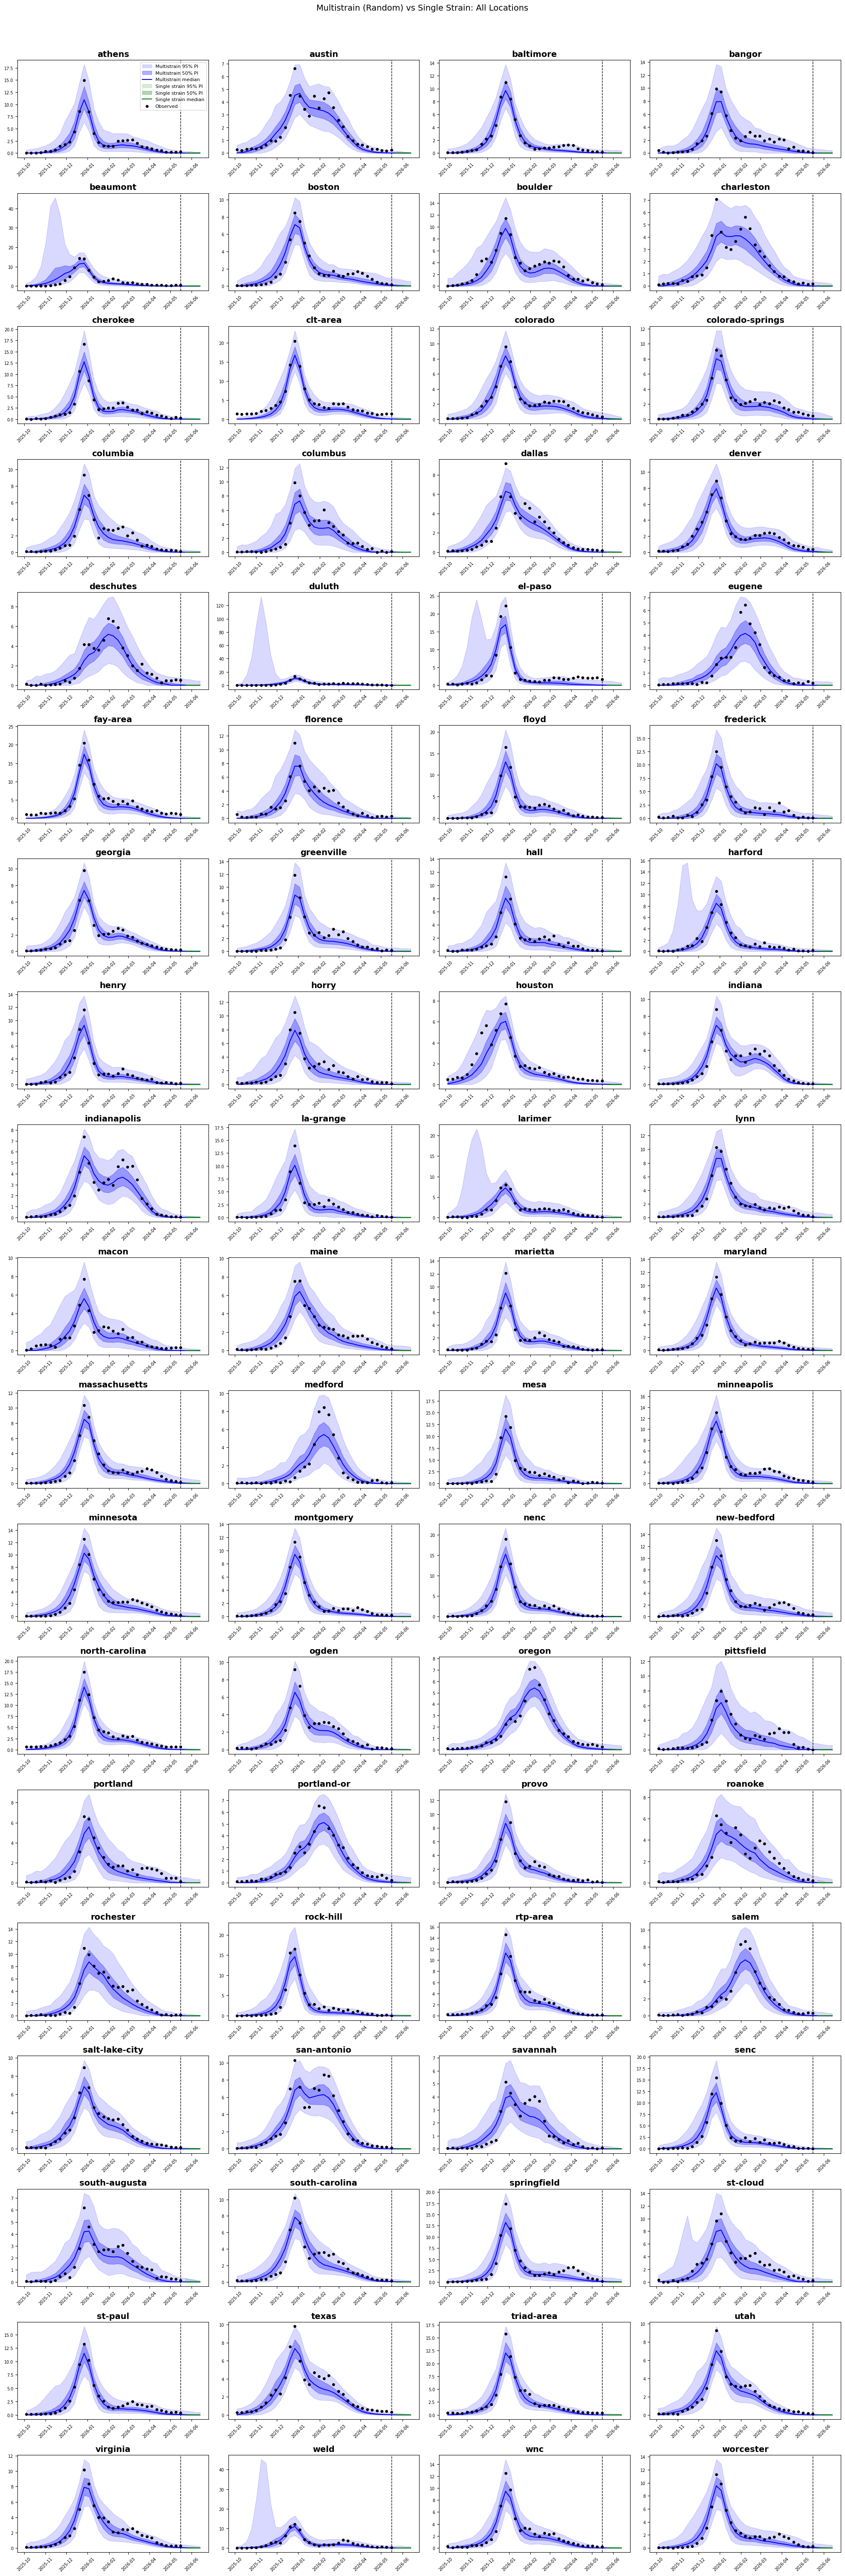

In [10]:
FILTER_PLOT = False
FILTER_PLOT_START = '2026-02-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    fname_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    fname_prefix = ''

if BASELINE:
    plot_title = f'Baseline (Beta var=mean/1000*{BASELINE_VAR_MULT}) Multistrain (Random) vs Single Strain: All Locations'
    fname_prefix += 'baseline_'
else:
    plot_title = 'Multistrain (Random) vs Single Strain: All Locations'

plot_fname = f"{fname_prefix}{MULTISTRAIN_EXPERIMENT}_multistrain_vs_single_comparison.pdf"

# Filter data
random_quantiles_filter = random_quantiles[
    (random_quantiles['date'] >= plot_start_date) &
    (random_quantiles['date'] < final_date)
]
fit_surv_data_filter = fit_surv_data[
    (fit_surv_data['date'] >= plot_start_date) &
    (fit_surv_data['date'] < final_date)
]

# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= plot_start_date) & 
    (df_single_wide['date'] < final_date)
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(19, 4, figsize=(20, 60))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    location_name = pop.replace("metrocast_location_", "")
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_name].sort_values('date')
    fit_surv_data_pop = fit_surv_data_filter[fit_surv_data_filter['location'] == location_name].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(fit_surv_data_pop['date'], fit_surv_data_pop['original_value'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(location_name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(plot_title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/{plot_fname}', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [11]:
# Create complete submission
submission = create_metro_submission(
    trajectories_df=random_combined,
    reference_date=REFERENCE_DATE,
    quantiles=get_metrocast_quantiles(),
    horizons=get_metrocast_horizons(),
    value_col=VALUE_COL
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (2736, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['Flu ED visits pct']
Length: 1, dtype: str
Output types: <StringArray>
['quantile']
Length: 1, dtype: str
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 76

Rows per target:
target             output_type
Flu ED visits pct  quantile       2736
dtype: int64


In [12]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-23,0,2026-05-23,athens,Flu ED visits pct,quantile,0.025,0.000
1,2026-05-23,0,2026-05-23,athens,Flu ED visits pct,quantile,0.05,0.000
2,2026-05-23,0,2026-05-23,athens,Flu ED visits pct,quantile,0.1,0.000
3,2026-05-23,0,2026-05-23,athens,Flu ED visits pct,quantile,0.25,0.000
4,2026-05-23,0,2026-05-23,athens,Flu ED visits pct,quantile,0.5,0.000
...,...,...,...,...,...,...,...,...
2731,2026-05-23,3,2026-06-13,worcester,Flu ED visits pct,quantile,0.5,0.000
2732,2026-05-23,3,2026-06-13,worcester,Flu ED visits pct,quantile,0.75,0.055
2733,2026-05-23,3,2026-06-13,worcester,Flu ED visits pct,quantile,0.9,0.168
2734,2026-05-23,3,2026-06-13,worcester,Flu ED visits pct,quantile,0.95,0.289


In [13]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"{WORKING_DIR}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)